# Wine Quality Dataset

## Before Preprocessing

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

df=pd.read_csv("D:\download\EffectOfDataPreprocessingInML\Datasets\WineQT.csv")
df.head(5)

from sklearn.model_selection import train_test_split
#df2 = df.copy()
X = df.drop('quality', axis=1)
y = df['quality']

from imblearn.over_sampling import SMOTE
print("Before SMOTE number of samples in each class label")
print(y.value_counts())
oversample = SMOTE(k_neighbors=3, random_state=42)
X, y = oversample.fit_resample(X,y)
print("After SMOTE (Synthetic Minority Over-sampling) number of samples in each class label")
print(y.value_counts())
print("\n")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# KNN Classifier 
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
knn_clf = KNeighborsClassifier(n_neighbors=3)
knn_clf.fit(X_train, y_train)

#Training Data Accuracy
y_pred_train = knn_clf.predict(X_train)
train_accuracy = accuracy_score(y_train, y_pred_train)
print("KNN train accuracy is:", round(train_accuracy,4))

#Testing Data Accuracy
y_pred_test = knn_clf.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred_test)
print("KNN test accuracy is:", round(test_accuracy,4)) 
print("\n")

# Logistic Regression
from sklearn.linear_model import LogisticRegression
lr_clf = LogisticRegression(max_iter=2000)
lr_clf.fit(X_train, y_train)

#Training Data Accuracy
y_pred_train = lr_clf.predict(X_train)
train_accuracy = accuracy_score(y_train, y_pred_train)
print("Logistic Regression train accuracy is:", round(train_accuracy,4))

#Testing Data Accuracy
y_pred_test = lr_clf.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred_test)
print("Logistic Regression test accuracy is:", round(test_accuracy,4))  
print("\n")

# Decision Tree
from sklearn.tree import DecisionTreeClassifier
dt_clf = DecisionTreeClassifier(random_state=10)
dt_clf.fit(X_train, y_train)

#Training Data Accuracy
y_pred_train = dt_clf.predict(X_train)
train_accuracy = accuracy_score(y_train, y_pred_train)
print("Decision Tree train accuracy is:", round(train_accuracy,4))

#Testing Data Accuracy
y_pred_test = dt_clf.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred_test)
print("Decision Tree test accuracy is:", round(test_accuracy,4)) 
print("\n")

Before SMOTE number of samples in each class label
quality
5    483
6    462
7    143
4     33
8     16
3      6
Name: count, dtype: int64
After SMOTE (Synthetic Minority Over-sampling) number of samples in each class label
quality
5    483
6    483
7    483
4    483
8    483
3    483
Name: count, dtype: int64


KNN train accuracy is: 0.8244
KNN test accuracy is: 0.6879


Logistic Regression train accuracy is: 0.5708
Logistic Regression test accuracy is: 0.5655


Decision Tree train accuracy is: 1.0
Decision Tree test accuracy is: 0.7724




## After Preprocessing

Dataset Shape: (1143, 12)
Before SMOTE number of samples in each class label
quality
5    483
6    462
7    143
4     33
8     16
3      6
Name: count, dtype: int64
After SMOTE (Synthetic Minority Over-sampling) number of samples in each class label
quality
5    483
6    483
7    483
4    483
8    483
3    483
Name: count, dtype: int64

KNN
Train Accuracy: 1.0
Test Accuracy: 0.8276

Classification Report:
              precision    recall  f1-score   support

           3       0.95      1.00      0.97        96
           4       0.85      0.98      0.91        96
           5       0.75      0.56      0.64        97
           6       0.60      0.49      0.54        97
           7       0.82      0.96      0.88        97
           8       0.93      0.98      0.95        97

    accuracy                           0.83       580
   macro avg       0.82      0.83      0.82       580
weighted avg       0.82      0.83      0.82       580


Sample Actual vs Predicted Values:
    Actual V

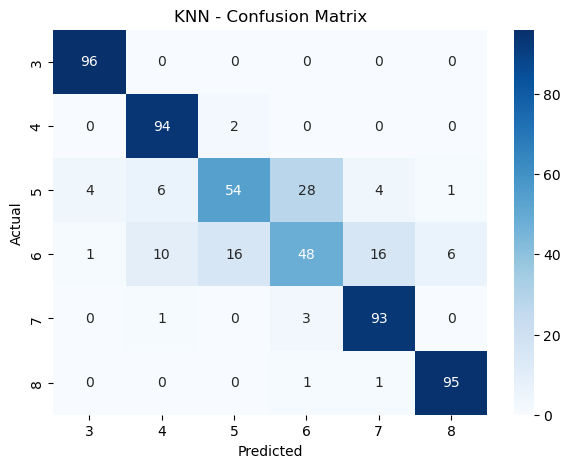

KNN Overall ROC-AUC Score: 0.9411


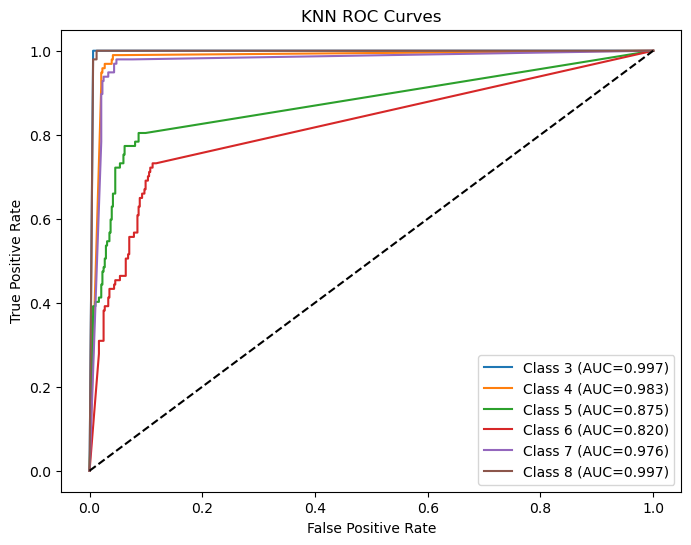


Logistic Regression
Train Accuracy: 0.6027
Test Accuracy: 0.6069

Classification Report:
              precision    recall  f1-score   support

           3       0.84      0.93      0.88        96
           4       0.53      0.46      0.49        96
           5       0.55      0.59      0.57        97
           6       0.44      0.29      0.35        97
           7       0.60      0.51      0.55        97
           8       0.60      0.88      0.71        97

    accuracy                           0.61       580
   macro avg       0.59      0.61      0.59       580
weighted avg       0.59      0.61      0.59       580


Sample Actual vs Predicted Values:
    Actual Value  Predicted Value
0              8                7
1              3                3
2              3                3
3              5                5
4              7                6
5              8                8
6              3                3
7              6                4
8              5         

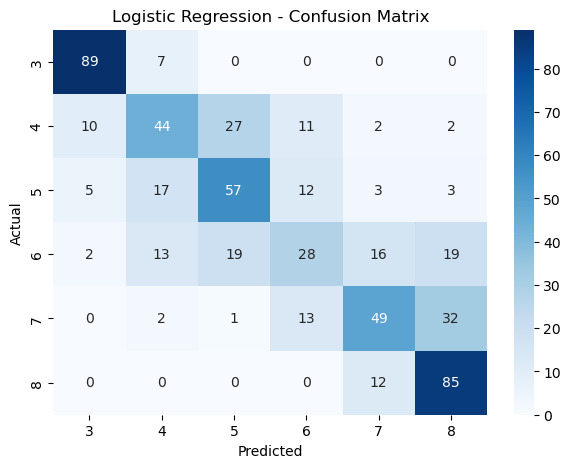

Logistic Regression Overall ROC-AUC Score: 0.8725


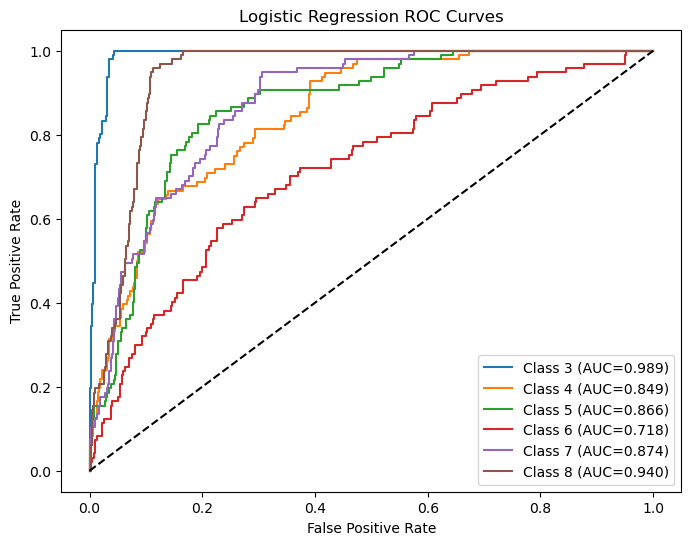


Decision Tree
Train Accuracy: 0.8136
Test Accuracy: 0.6966

Classification Report:
              precision    recall  f1-score   support

           3       0.91      0.94      0.92        96
           4       0.71      0.67      0.69        96
           5       0.53      0.52      0.52        97
           6       0.41      0.43      0.42        97
           7       0.72      0.74      0.73        97
           8       0.92      0.89      0.91        97

    accuracy                           0.70       580
   macro avg       0.70      0.70      0.70       580
weighted avg       0.70      0.70      0.70       580


Sample Actual vs Predicted Values:
    Actual Value  Predicted Value
0              8                8
1              3                3
2              3                3
3              5                5
4              7                6
5              8                8
6              3                3
7              6                4
8              5               

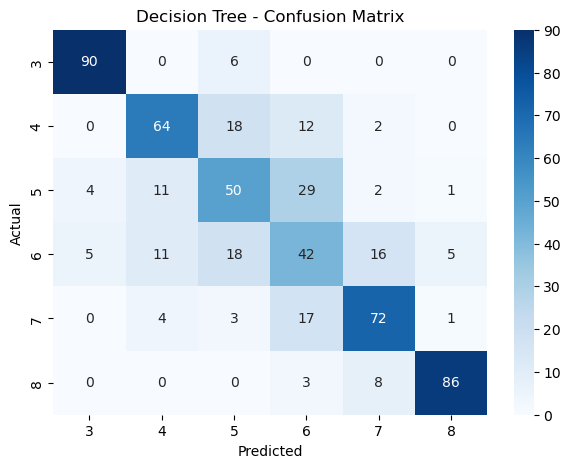

Decision Tree Overall ROC-AUC Score: 0.9048


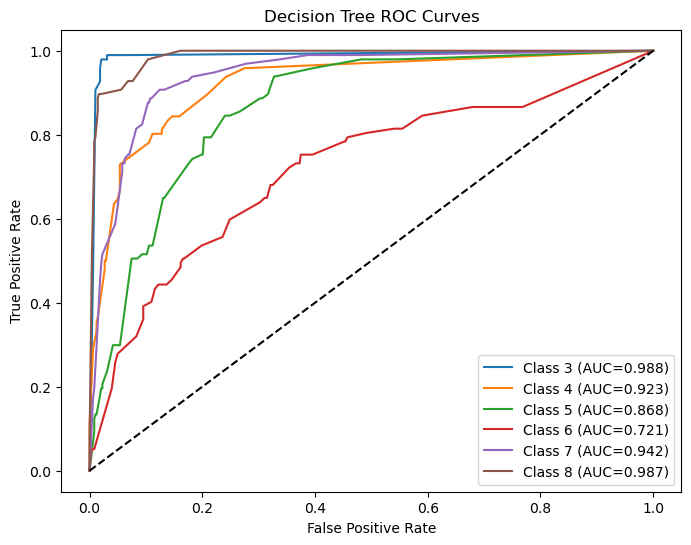

In [11]:
import pandas as pd
import numpy as np
from sklearn.impute import KNNImputer
from sklearn.preprocessing import RobustScaler, label_binarize, MaxAbsScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (confusion_matrix, accuracy_score, roc_auc_score, roc_curve, classification_report)
import seaborn as sns
import matplotlib.pyplot as plt

# 1. LOAD DATA
df = pd.read_csv(r"D:\download\EffectOfDataPreprocessingInML\DatasetS\WineQT-1.csv")
df=df.drop(columns=["Id"])
print("Dataset Shape:", df.shape)
df.head()

# 2. MEAN IMPUTATION TO REPLACE MISSING VALUES
df_mean_imputed = df.fillna(df.mean())

X = df_mean_imputed.drop("quality", axis=1)
y = df_mean_imputed["quality"]

# 3. ROBUST SCALER 
robust_scaler = RobustScaler()
X_robust_scaled = pd.DataFrame(robust_scaler.fit_transform(X), columns=X.columns)

# 4. MAX ABSOLUTE NORMALIZATION
maxabs_scaler = MaxAbsScaler()
X_maxabs_scaled = pd.DataFrame(maxabs_scaler.fit_transform(X_robust_scaled), columns=X.columns)

# 5. SMOTE
print("Before SMOTE number of samples in each class label")
print(y.value_counts())

from imblearn.over_sampling import SMOTE
oversample = SMOTE(k_neighbors=4, random_state=42)
X_maxabs_scaled, y = oversample.fit_resample(X_maxabs_scaled,y)

print("After SMOTE (Synthetic Minority Over-sampling) number of samples in each class label")
print(y.value_counts())

X_train, X_test, y_train, y_test = train_test_split(
    X_maxabs_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# 6. --- KNN ---
knn = KNeighborsClassifier(n_neighbors=3, weights='distance')
knn.fit(X_train, y_train)

# 7. --- Logistic Regression ---
logreg = LogisticRegression(
    multi_class='multinomial',
    solver='lbfgs',
    class_weight='balanced',
    max_iter=5000
)
logreg.fit(X_train, y_train)

# 8. --- Decision Tree ---
dt = DecisionTreeClassifier(
    max_depth=8,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight='balanced',
    criterion='entropy',
    random_state=42
)
dt.fit(X_train, y_train)

# 9. ACCURACY RESULTS
models = {
    "KNN":knn,
    "Logistic Regression":logreg,
    "Decision Tree":dt
}

for name, model in models.items():
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    print(f"\n{name}")
    train_acc = accuracy_score(y_train, y_pred_train)
    test_acc = accuracy_score(y_test, y_pred_test) 
    print("Train Accuracy:", round(train_acc, 4))
    print("Test Accuracy:", round(test_acc, 4))

    # Classification Report
    print("\nClassification Report:")
    print(classification_report(y_test,y_pred_test))

    comparison_df = pd.DataFrame({
        "Actual Value": y_test.values,
        "Predicted Value": y_pred_test
     })
    
    print("\nSample Actual vs Predicted Values:")
    print(comparison_df.head(15))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred_test)
    
    # Actual class labels
    classes = sorted(y.unique())
    
    plt.figure(figsize=(7,5))
    
    sns.heatmap(
        cm,
        annot=True,
        cmap="Blues",
        fmt="d",
        xticklabels=classes,
        yticklabels=classes
    )
    
    plt.title(f"{name} - Confusion Matrix")
    
    plt.xlabel("Predicted")
    
    plt.ylabel("Actual")
    
    plt.show()
    #ROC Score
    y_test_bin = label_binarize(y_test, classes=classes)

    y_score = model.predict_proba(X_test)
    
    overall_auc = roc_auc_score(
        y_test_bin,
        y_score,
        multi_class="ovr",
        average="macro"
    )
    
    print(f"{name} Overall ROC-AUC Score: {overall_auc:.4f}")
    #ROC Plot
    plt.figure(figsize=(8,6))
    
    for i, cls in enumerate(classes):
    
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    
        class_auc = roc_auc_score(
            y_test_bin[:, i],
            y_score[:, i]
        )
    
        plt.plot(
            fpr,
            tpr,
            label=f"Class {cls} (AUC={class_auc:.3f})"
        )
    
    plt.plot([0,1], [0,1], 'k--') 
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{name} ROC Curves")
    plt.legend() 
    plt.show()

## Heart Disease Data

In [7]:
df=pd.read_csv(r"D:\download\EffectOfDataPreprocessingInML\Datasets\heart_disease.csv")
df.head(5)

,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,...,High LDL Cholesterol,Alcohol Consumption,Stress Level,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status
0,56.0,Male,153.0,155.0,High,Yes,Yes,No,24.991591,Yes,...,No,High,Medium,7.633228,Medium,342.0,NaN,12.969246,12.387250,No
1,69.0,Female,146.0,286.0,High,No,Yes,Yes,25.221799,No,...,No,Medium,High,8.744034,Medium,133.0,157.0,9.355389,19.298875,No
2,46.0,Male,126.0,216.0,Low,No,No,No,29.855447,No,...,Yes,Low,Low,4.440440,Low,393.0,92.0,12.709873,11.230926,No
3,32.0,Female,122.0,293.0,High,Yes,Yes,No,24.130477,Yes,...,Yes,Low,High,5.249405,High,293.0,94.0,12.509046,5.961958,No
4,60.0,Male,166.0,242.0,Low,Yes,Yes,Yes,20.486289,Yes,...,No,Low,High,7.030971,High,263.0,154.0,10.381259,8.153887,No


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Age                   9971 non-null   float64
 1   Gender                9981 non-null   object 
 2   Blood Pressure        9981 non-null   float64
 3   Cholesterol Level     9970 non-null   float64
 4   Exercise Habits       9975 non-null   object 
 5   Smoking               9975 non-null   object 
 6   Family Heart Disease  9979 non-null   object 
 7   Diabetes              9970 non-null   object 
 8   BMI                   9978 non-null   float64
 9   High Blood Pressure   9974 non-null   object 
 10  Low HDL Cholesterol   9975 non-null   object 
 11  High LDL Cholesterol  9974 non-null   object 
 12  Alcohol Consumption   7414 non-null   object 
 13  Stress Level          9978 non-null   object 
 14  Sleep Hours           9975 non-null   float64
 15  Sugar Consumption   

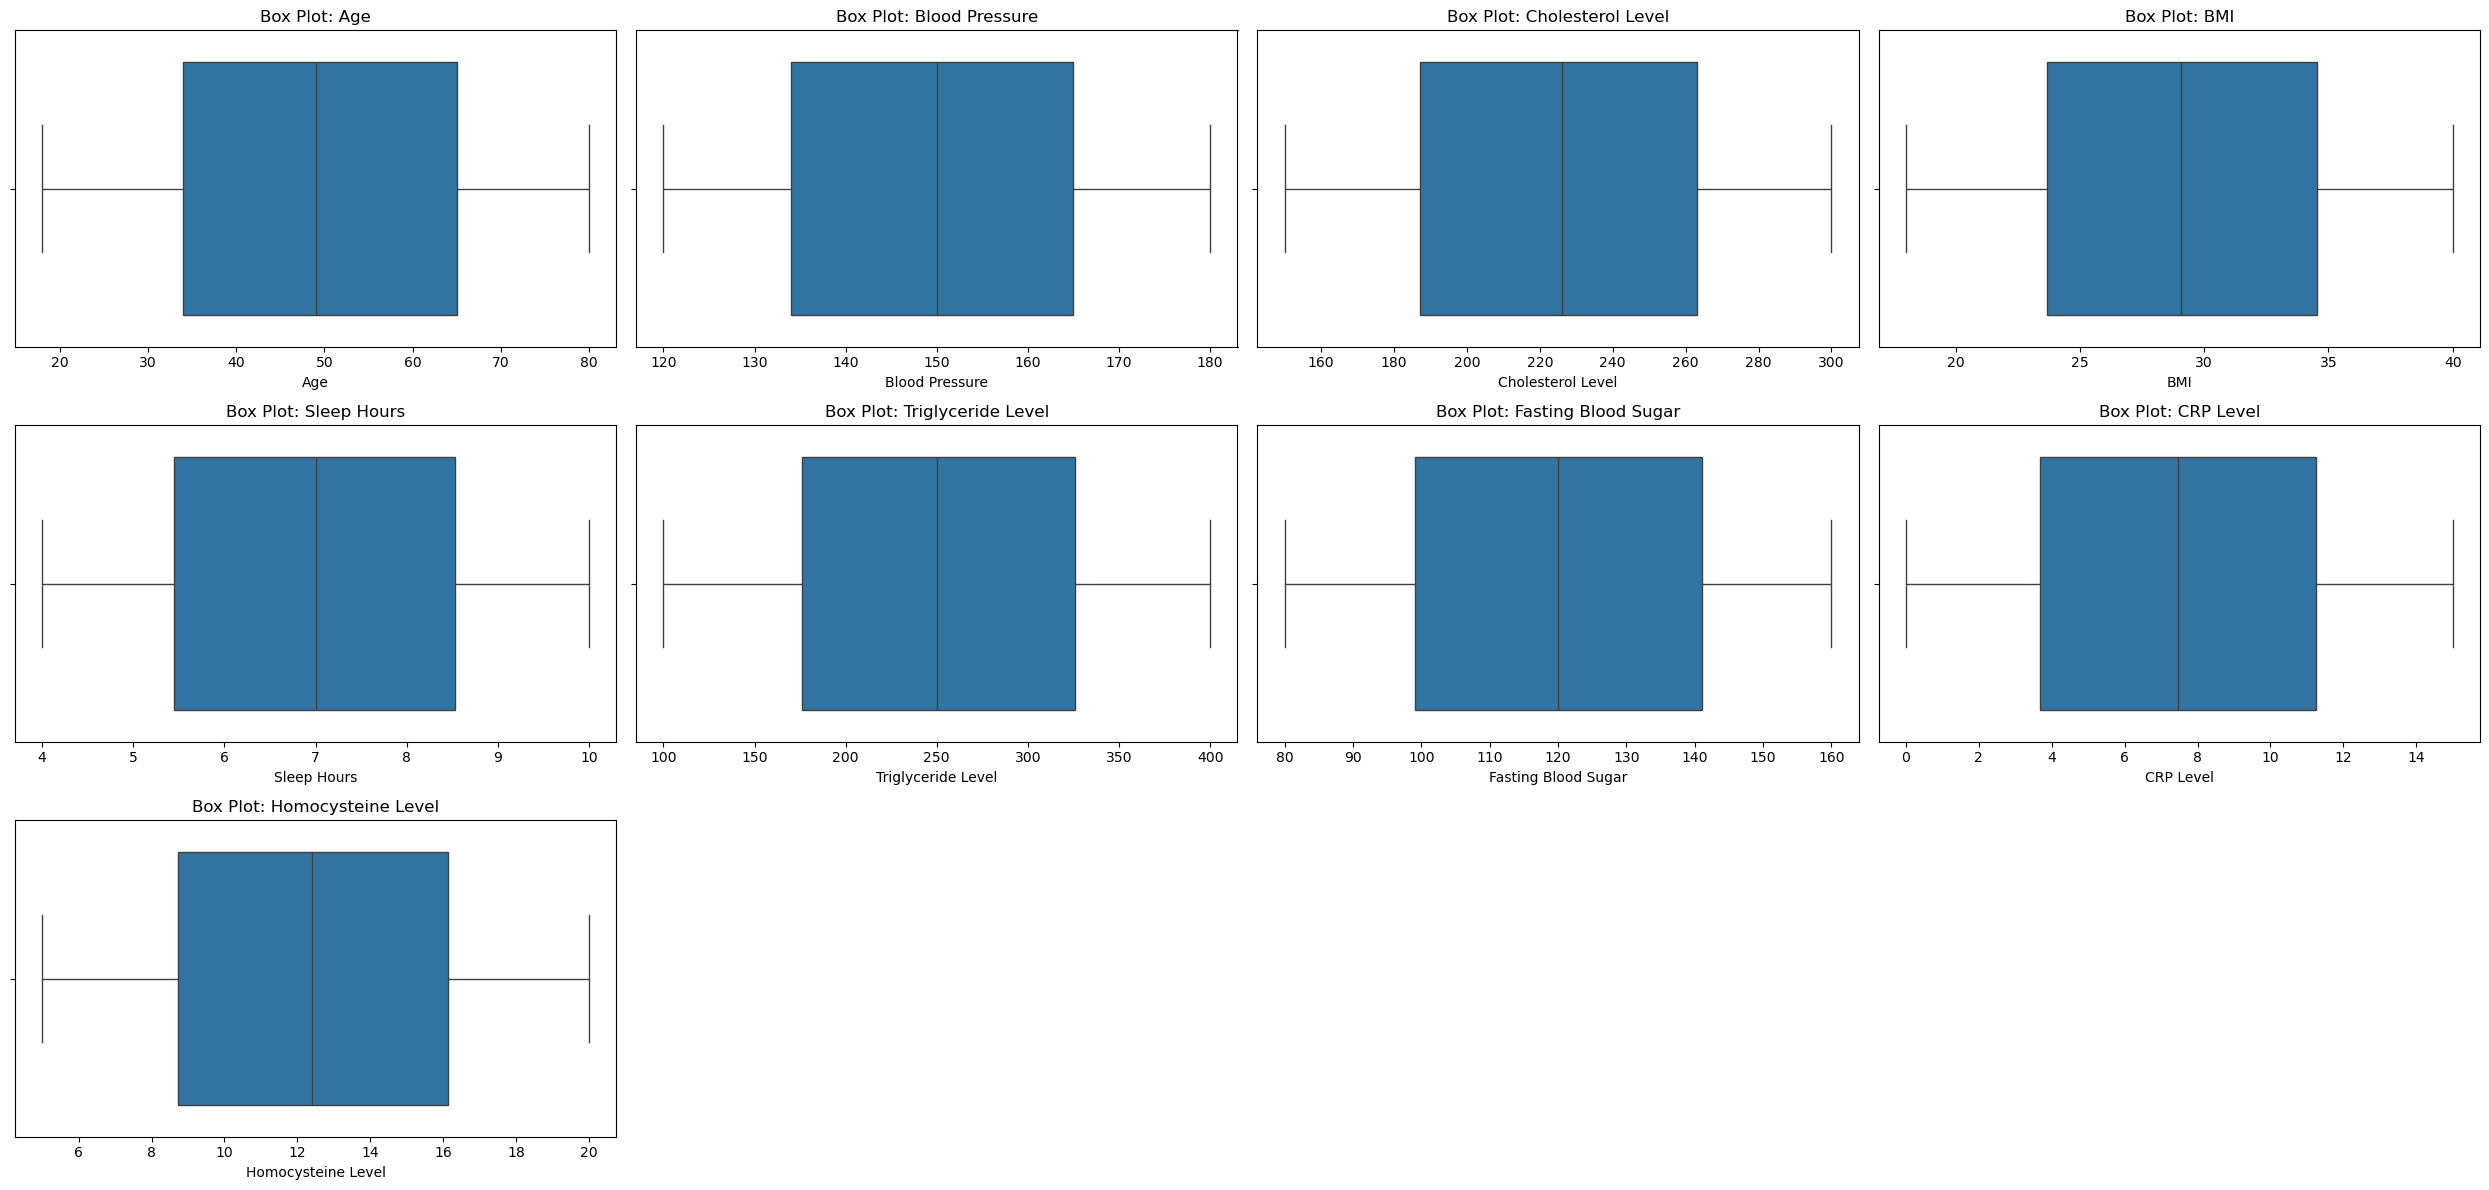

In [9]:
# Box Plot to detect outliers
numeric_cols = df.select_dtypes(include='float64').columns
plt.figure(figsize=(25, 12))  
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(3, 4, i)
    sns.boxplot(x=df[col])     
    plt.title(f"Box Plot: {col}")
    plt.xlabel(col)
plt.tight_layout()
plt.show()

Dataset Shape: (10000, 20)

Ordinal Encoded Column: Exercise Habits
{'low': 0, 'medium': 1, 'high': 2}

Ordinal Encoded Column: Alcohol Consumption
{'low': 0, 'medium': 1, 'high': 2}

Ordinal Encoded Column: Stress Level
{'low': 0, 'medium': 1, 'high': 2}

Ordinal Encoded Column: Sugar Consumption
{'low': 0, 'medium': 1, 'high': 2}

Label Encoded Column: Smoking
{'no': np.int64(0), 'yes': np.int64(1)}

Label Encoded Column: Family Heart Disease
{'no': np.int64(0), 'yes': np.int64(1)}

Label Encoded Column: Diabetes
{'no': np.int64(0), 'yes': np.int64(1)}

Label Encoded Column: High Blood Pressure
{'no': np.int64(0), 'yes': np.int64(1)}

Label Encoded Column: Low HDL Cholesterol
{'no': np.int64(0), 'yes': np.int64(1)}

Label Encoded Column: High LDL Cholesterol
{'no': np.int64(0), 'yes': np.int64(1)}

Label Encoded Column: Heart Disease Status
{'no': np.int64(0), 'yes': np.int64(1)}

Selected Features:
Index(['Age', 'Blood Pressure', 'Family Heart Disease', 'BMI',
       'High LDL Chole

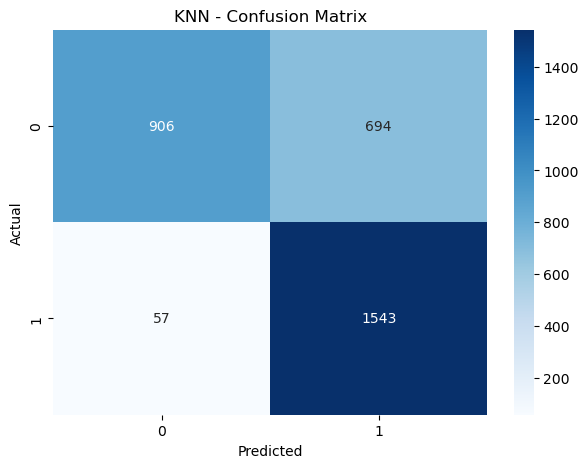

KNN ROC-AUC Score: 0.8990


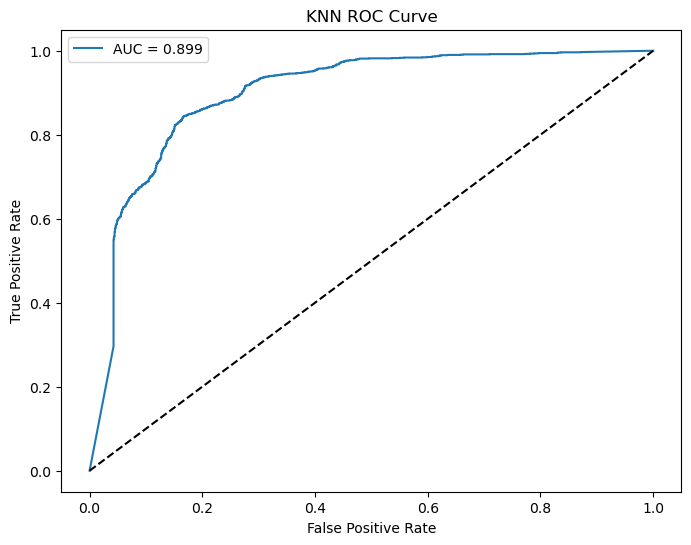


Logistic Regression
Train Accuracy: 0.5172
Test Accuracy: 0.525

Classification Report:
              precision    recall  f1-score   support

           0       0.52      0.53      0.53      1600
           1       0.53      0.52      0.52      1600

    accuracy                           0.53      3200
   macro avg       0.53      0.52      0.52      3200
weighted avg       0.53      0.53      0.52      3200


Sample Actual vs Predicted Values:
    Actual Value  Predicted Value
0              1                0
1              1                1
2              0                0
3              1                0
4              1                1
5              0                1
6              1                1
7              1                0
8              1                0
9              1                1
10             0                1
11             1                0
12             1                1
13             0                1
14             1                0


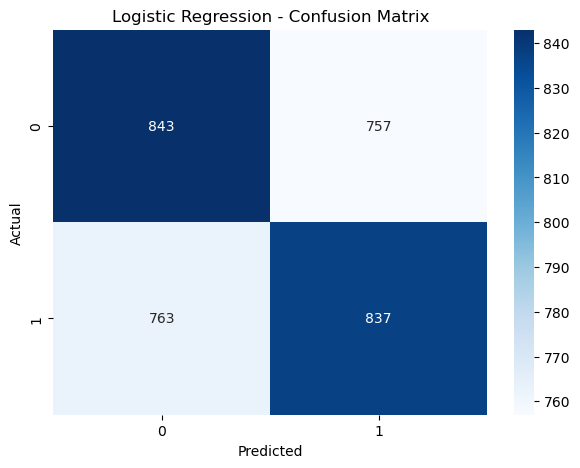

Logistic Regression ROC-AUC Score: 0.5317


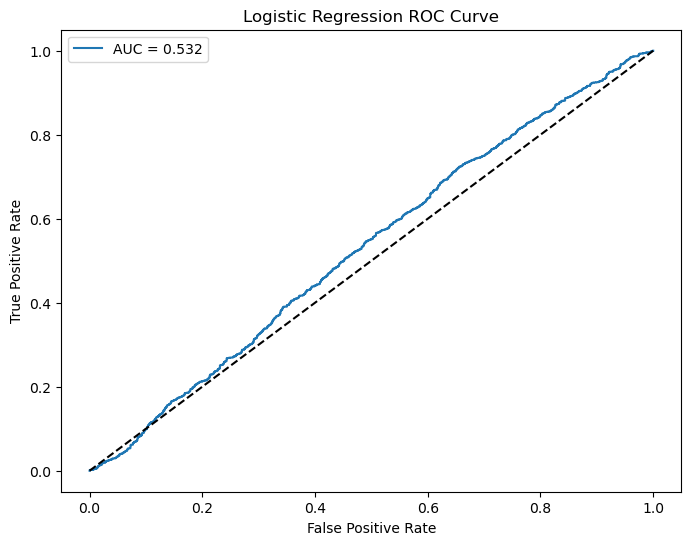


Decision Tree
Train Accuracy: 0.5982
Test Accuracy: 0.5769

Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.24      0.36      1600
           1       0.55      0.92      0.68      1600

    accuracy                           0.58      3200
   macro avg       0.64      0.58      0.52      3200
weighted avg       0.64      0.58      0.52      3200


Sample Actual vs Predicted Values:
    Actual Value  Predicted Value
0              1                1
1              1                1
2              0                1
3              1                1
4              1                1
5              0                1
6              1                1
7              1                1
8              1                1
9              1                1
10             0                1
11             1                1
12             1                1
13             0                0
14             1                0


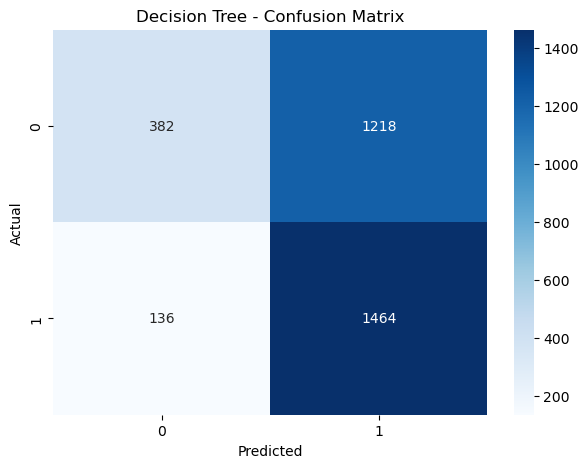

Decision Tree ROC-AUC Score: 0.5999


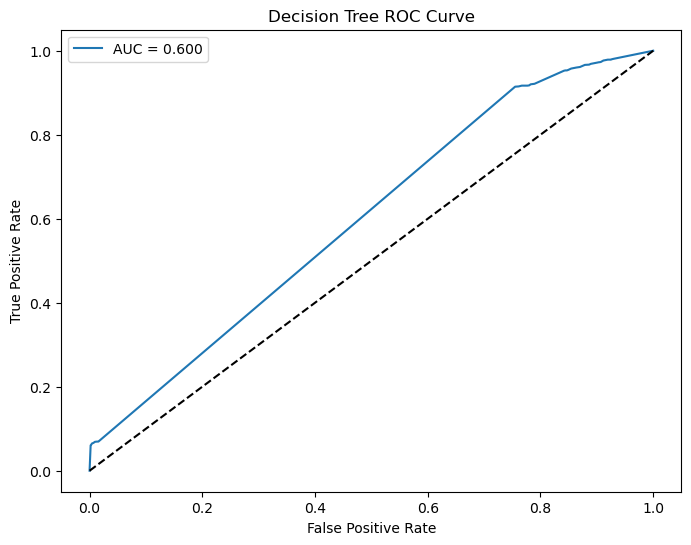

In [19]:
import pandas as pd
import numpy as np
from sklearn.impute import KNNImputer
from sklearn.preprocessing import (StandardScaler,MinMaxScaler,LabelEncoder,OrdinalEncoder)

from sklearn.model_selection import train_test_split
from sklearn.feature_selection import (SelectKBest,f_classif)

from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (confusion_matrix,accuracy_score,roc_auc_score,roc_curve,classification_report)

from imblearn.over_sampling import SMOTE

import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv(r"D:\download\EffectOfDataPreprocessingInML\Datasets\heart_disease.csv")

df = df.drop(columns=["Gender"])

print("Dataset Shape:", df.shape)

for col in df.select_dtypes(include='object').columns:

    df[col] = df[col].apply(
        lambda x: x.strip().lower()
        if isinstance(x, str)
        else x
    )

ordinal_encoder = OrdinalEncoder(categories=[['low', 'medium', 'high']])

for col in df.select_dtypes(include='object').columns:

    unique_values = set(df[col].dropna().unique())

    if unique_values.issubset(
        {"low", "medium", "high"}
    ):

        non_null = df[[col]].dropna()

        ordinal_encoder.fit(non_null)

        df.loc[df[col].notna(), col] = (
            ordinal_encoder.transform(non_null)
        )

        print(f"\nOrdinal Encoded Column: {col}")

        #ordinal encoding mapping
        mapping = dict(
            zip(
                ordinal_encoder.categories_[0],
                range(len(ordinal_encoder.categories_[0]))
            )
        )

        print(mapping)

# LABEL ENCODING

label_encoder = LabelEncoder()

for col in df.select_dtypes(include='object').columns:

    unique_values = set(df[col].dropna().unique())

    # Apply Label Encoding for binary categorical columns
    if unique_values.issubset({"yes", "no"}):

        non_null = df[col].dropna()

        # Fit and transform
        df.loc[df[col].notna(), col] = label_encoder.fit_transform(non_null)

        print(f"\nLabel Encoded Column: {col}")

        # Show encoding mapping
        mapping = dict(
            zip(
                label_encoder.classes_,
                label_encoder.transform(label_encoder.classes_)
            )
        )

        print(mapping)

X = df.drop("Heart Disease Status",axis=1)

y = df["Heart Disease Status"].astype(int)

imputer = KNNImputer(n_neighbors=3)

X_imputed = pd.DataFrame(
    imputer.fit_transform(X),
    columns=X.columns
)

standard_scaler = StandardScaler()

X_standard_scaled = pd.DataFrame(
    standard_scaler.fit_transform(X_imputed),
    columns=X.columns
)

minmax_scaler = MinMaxScaler()

X_minmax_scaled = pd.DataFrame(
    minmax_scaler.fit_transform(X_standard_scaled),
    columns=X.columns
)
 
selector = SelectKBest(score_func=f_classif,k=10)

X_selected = selector.fit_transform(X_minmax_scaled,y)

selected_features = X.columns[selector.get_support()]

print("\nSelected Features:")
print(selected_features)

X_minmax_scaled = pd.DataFrame(X_selected,columns=selected_features)

print("\nPre-processed Data:")
print(X_minmax_scaled.head(15))

print("\nBefore SMOTE:")
print(y.value_counts())

oversample = SMOTE(k_neighbors=4,random_state=42)

X_minmax_scaled, y = oversample.fit_resample(X_minmax_scaled,y)

print("\nAfter SMOTE:")
print(y.value_counts())

X_train, X_test, y_train, y_test = train_test_split(X_minmax_scaled,y,test_size=0.2,random_state=42,stratify=y)

knn = KNeighborsClassifier(
    n_neighbors=7,
    weights='distance',
    metric='minkowski',
    p=2
)

knn.fit(X_train,y_train)

logreg = LogisticRegression(
    solver='liblinear',
    C=3,
    penalty='l2',
    max_iter=20000,
    class_weight='balanced'
)

logreg.fit(X_train,y_train)

dt = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=10,
    min_samples_split=15,
    min_samples_leaf=8,
    max_features=None,
    class_weight='balanced',
    random_state=42
)

dt.fit(X_train,y_train)

models = {
    "KNN": knn,
    "Logistic Regression": logreg,
    "Decision Tree": dt
}

for name, model in models.items():

    # PREDICTIONS
    y_pred_train = model.predict(X_train)

    y_pred_test = model.predict(X_test)

    print(f"\n{name}")

    # ACCURACY
    train_acc = accuracy_score(y_train, y_pred_train)

    test_acc = accuracy_score(y_test,y_pred_test)

    print("Train Accuracy:",round(train_acc, 4))

    print("Test Accuracy:",round(test_acc, 4))

    # CLASSIFICATION REPORT
    print("\nClassification Report:")

    print(classification_report(y_test,y_pred_test))

    # ACTUAL VS PREDICTED
    comparison_df = pd.DataFrame({"Actual Value": y_test.values,"Predicted Value": y_pred_test})

    print("\nSample Actual vs Predicted Values:")

    print(comparison_df.head(15))

    # CONFUSION MATRIX
    cm = confusion_matrix(y_test,y_pred_test)

    plt.figure(figsize=(7,5))

    sns.heatmap(cm,annot=True,cmap="Blues",fmt="d")

    plt.title(f"{name} - Confusion Matrix")

    plt.xlabel("Predicted")

    plt.ylabel("Actual")

    plt.show()

    # ROC AUC SCORE
    y_score = model.predict_proba(X_test)[:, 1]

    auc_score = roc_auc_score(y_test,y_score)

    print(f"{name} ROC-AUC Score: "f"{auc_score:.4f}")

    # ROC CURVE
    fpr, tpr, thresholds = roc_curve(y_test,y_score)

    plt.figure(figsize=(8,6))

    plt.plot(fpr,tpr,label=f"AUC = {auc_score:.3f}")

    plt.plot([0,1],[0,1],'k--')

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{name} ROC Curve")
    plt.legend()
    plt.show()